In [6]:
# Markdown cell in Jupyter:
# Name: Pavani Chavali
# Course: Advanced Big Data and Data Mining
# Assignment: Lab 1 - Data Visualization, Preprocessing, and Statistical Analysis

# Python code cell:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Ensure visualizations display inline
%matplotlib inline

# Load the dataset.
df = pd.read_csv('./Lab1/retail_sales_dataset.csv')

# 2. Convert order_date to datetime format for accurate time-series analysis later
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Screenshot Required: Display the first five rows
display(df.head())

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,...,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,...,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,...,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,...,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,...,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0


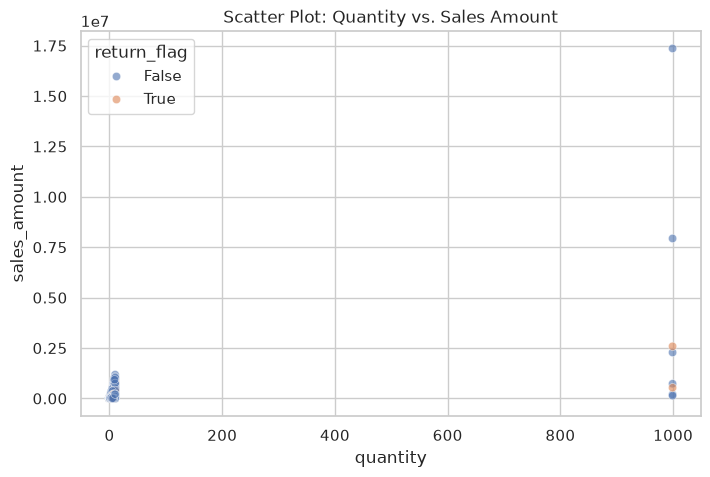

In [16]:
sns.set_theme(style="whitegrid")

# 1. Scatter Plot: Quantity vs. Sales Amount
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='quantity', y='sales_amount', hue='return_flag', alpha=0.6)
plt.title('Scatter Plot: Quantity vs. Sales Amount')
plt.show()

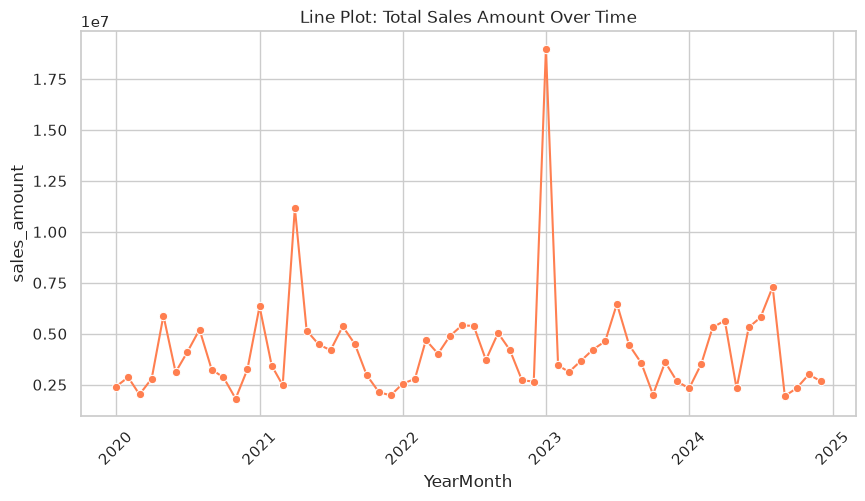

In [17]:
# 2. Line Plot: Monthly Sales Trend Over Time
# Group by month and calculate the sum of sales
df_trend = df.dropna(subset=['order_date']).copy()
df_trend['YearMonth'] = df_trend['order_date'].dt.to_period('M')
monthly_sales = df_trend.groupby('YearMonth')['sales_amount'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].dt.to_timestamp() # Convert back for plotting

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_sales, x='YearMonth', y='sales_amount', marker='o', color='coral')
plt.title('Line Plot: Total Sales Amount Over Time')
plt.xticks(rotation=45)
plt.show()

/tmp/xpython_42/2440824782.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='product_category', y='sales_amount', estimator=sum, ci=None, palette='viridis')
/tmp/xpython_42/2440824782.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='product_category', y='sales_amount', estimator=sum, ci=None, palette='viridis')


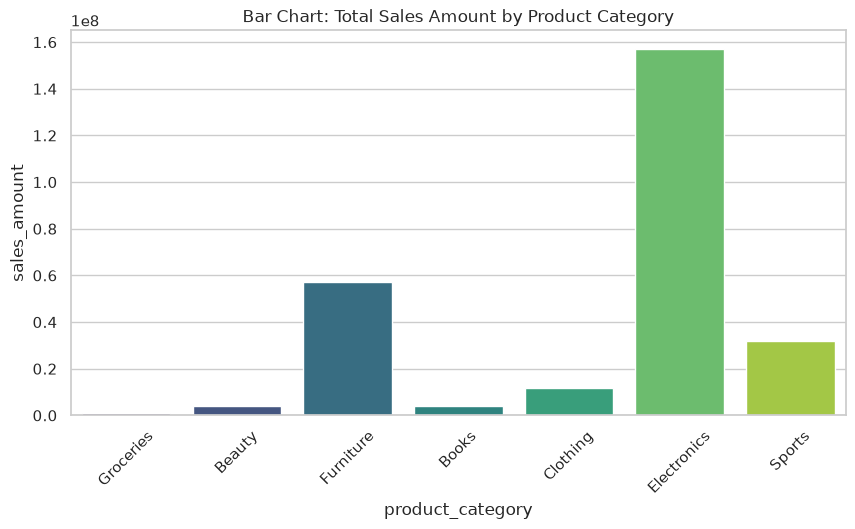

In [18]:
# 3. Bar Chart: Total Sales by Product Category
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='product_category', y='sales_amount', estimator=sum, ci=None, palette='viridis')
plt.title('Bar Chart: Total Sales Amount by Product Category')
plt.xticks(rotation=45)
plt.show()

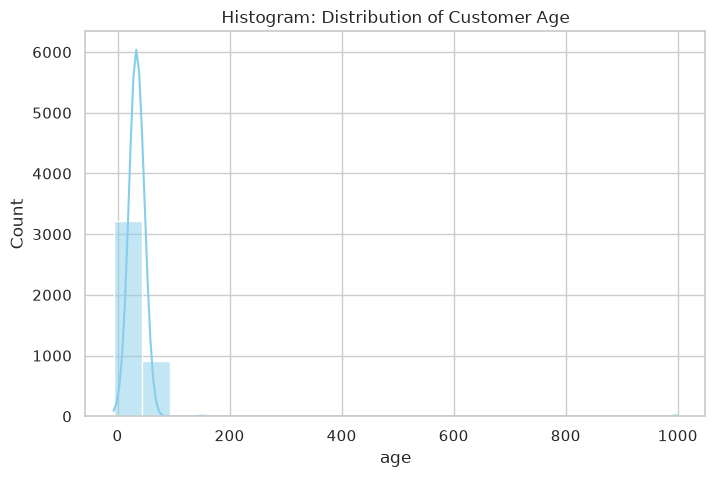

In [19]:
# 4. Histogram: Distribution of Customer Ages
plt.figure(figsize=(8, 5))
sns.histplot(df['age'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Histogram: Distribution of Customer Age')
plt.show()

/tmp/xpython_42/1088296440.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='profit', palette='Set2')


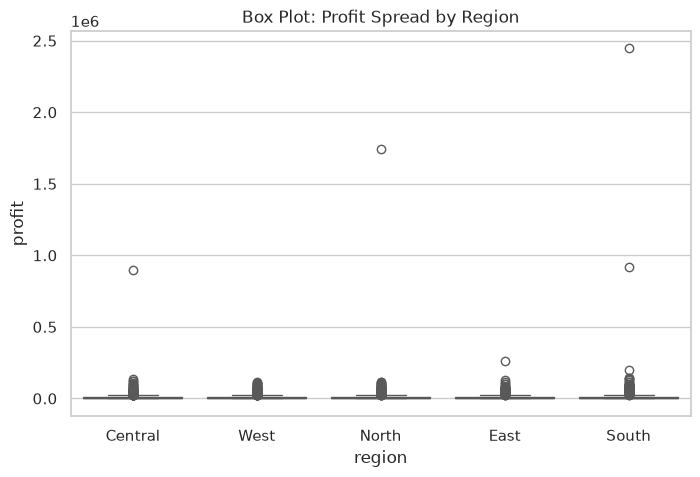

In [20]:
# 5. Box Plot: Profit Distribution by Region
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='region', y='profit', palette='Set2')
plt.title('Box Plot: Profit Spread by Region')
plt.show()

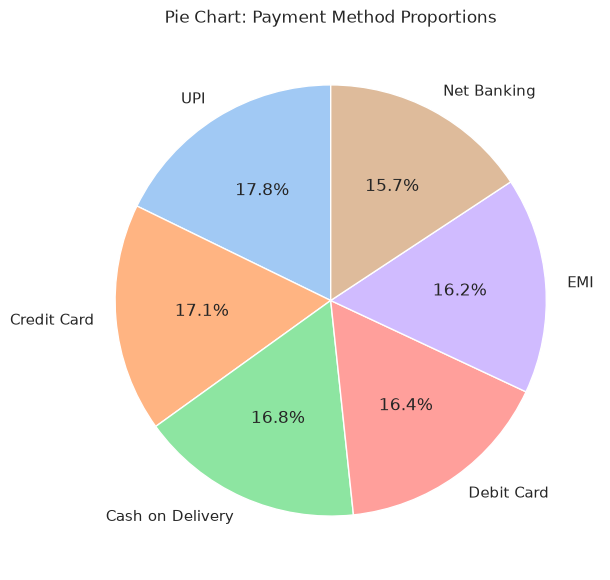

In [21]:
# 6. Pie Chart: Proportions of Payment Methods
plt.figure(figsize=(7, 7))
payment_counts = df['payment_method'].value_counts()
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Pie Chart: Payment Method Proportions')
plt.show()

In [23]:
# --- 1. Handling Missing Values ---
print("Missing Values Before:")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Only show columns with missing data

Missing Values Before:
order_id             30
order_date          303
customer_id          30
customer_name        30
gender               30
region               30
city                 30
product_category     30
product_name         30
unit_price           30
sales_amount         30
profit               30
shipping_cost        30
payment_method       30
return_flag          30
order_status         30
dtype: int64


In [24]:
# Fill missing numeric values with mean or median
df['age'] = df['age'].fillna(df['age'].median())
df['quantity'] = df['quantity'].fillna(df['quantity'].median())
df['discount_pct'] = df['discount_pct'].fillna(0) # Assume NaN means 0 discount
df['customer_satisfaction'] = df['customer_satisfaction'].fillna(df['customer_satisfaction'].mean())
df['days_to_ship'] = df['days_to_ship'].fillna(df['days_to_ship'].median())

In [27]:
# Drop rows that still have critical categorical/date data missing
df_clean = df.dropna(subset=['order_id', 'customer_id', 'product_category', 'order_date'])

print("\nMissing Values After:")
print(df_clean.isnull().sum().max()) 


Missing Values After:
0


In [33]:
# --- 2. Outlier Detection and Removal (using IQR on 'sales_amount') ---
Q1 = df_clean['sales_amount'].quantile(0.25)
Q3 = df_clean['sales_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify and remove
outliers = df_clean[(df_clean['sales_amount'] < lower_bound) | (df_clean['sales_amount'] > upper_bound)]
df_no_outliers = df_clean[(df_clean['sales_amount'] >= lower_bound) & (df_clean['sales_amount'] <= upper_bound)]

print(f"\nIdentified {len(outliers)} outliers in sales_amount.")
print(f"Shape before outliers: {df_clean.shape}, Shape after: {df_no_outliers.shape}")


Identified 554 outliers in sales_amount.
Shape before outliers: (4007, 21), Shape after: (3453, 21)


In [34]:
# --- 3. Data Reduction ---
# Dimension elimination: Drop non-analytical IDs and redundant names
df_reduced = df_no_outliers.drop(columns=['order_id', 'customer_id', 'customer_name'])
# Sampling: Reduce data to 80% randomly
df_sampled = df_reduced.sample(frac=0.8, random_state=42)

print("\nShape after Data Reduction (Column Drop & Sampling):", df_sampled.shape)


Shape after Data Reduction (Column Drop & Sampling): (2762, 18)


In [35]:
!mamba install scikit-learn

# --- 4. Data Scaling and Discretization ---
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df_final = df_sampled.copy()

# Min-Max Scaling on unit_price
min_max = MinMaxScaler()
df_final['unit_price_scaled'] = min_max.fit_transform(df_final[['unit_price']])

# Z-score Standardization on profit
std_scaler = StandardScaler()
df_final['profit_standardized'] = std_scaler.fit_transform(df_final[['profit']])

# Discretize continuous age data into categorical bins
bins = [0, 25, 55, 100]
labels = ['Youth', 'Adult', 'Senior']
df_final['Age_Group'] = pd.cut(df_final['age'], bins=bins, labels=labels)

display(df_final[['unit_price', 'unit_price_scaled', 'profit', 'profit_standardized', 'age', 'Age_Group']].head())
St

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.930 seconds
All requested packages already installed.


,unit_price,unit_price_scaled,profit,profit_standardized,age,Age_Group
651,276.93,0.002861,275.46,-0.672880,45.0,Adult
64,11157.11,0.141181,3797.24,-0.122790,22.0,Youth
2356,1501.94,0.018434,579.92,-0.625324,40.0,Adult
962,469.65,0.005311,185.80,-0.686884,58.0,Senior
703,2755.32,0.034369,6803.51,0.346779,39.0,Adult


<class 'NameError'>: name 'St' is not defined

In [36]:
#Step 4: Statistical Analysis
# 1. General Overview of Data
print("--- Data Info ---")
df_final.info()
print("\n--- Data Describe ---")
display(df_final.describe())

# Select only numeric columns for statistical math
numeric_cols = df_final.select_dtypes(include=[np.number])

# 2. Central Tendency Measures
print("\n--- Central Tendency ---")
print("Mean:\n", numeric_cols.mean().head()) 
print("\nMedian:\n", numeric_cols.median().head())
print("\nMode (Top categorical product):\n", df_final['product_category'].mode().iloc[0])

# 3. Dispersion Measures
print("\n--- Dispersion Measures ---")
print("Range:\n", (numeric_cols.max() - numeric_cols.min()).head())
print("\nVariance:\n", numeric_cols.var().head())
print("\nStandard Deviation:\n", numeric_cols.std().head())

# IQR Calculation
q1 = numeric_cols.quantile(0.25)
q3 = numeric_cols.quantile(0.75)
print("\nInterquartile Range (IQR):\n", (q3 - q1).head())

# 4. Correlation Analysis
print("\n--- Correlation Matrix ---")
corr_matrix = numeric_cols.corr()
display(corr_matrix)

--- Data Info ---
<class 'pandas.DataFrame'>
Index: 2762 entries, 651 to 1185
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_date             2762 non-null   datetime64[us]
 1   age                    2762 non-null   float64       
 2   gender                 2762 non-null   str           
 3   region                 2762 non-null   str           
 4   city                   2762 non-null   str           
 5   product_category       2762 non-null   str           
 6   product_name           2762 non-null   str           
 7   quantity               2762 non-null   float64       
 8   unit_price             2762 non-null   float64       
 9   discount_pct           2762 non-null   float64       
 10  sales_amount           2762 non-null   float64       
 11  profit                 2762 non-null   float64       
 12  shipping_cost          2762 non-null   float64       
 13 

,order_date,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship,unit_price_scaled,profit_standardized
count,2762,2762.000000,2762.000000,2762.000000,2762.000000,2762.000000,2762.000000,2762.000000,2762.000000,2762.000000,2762.000000,2.762000e+03
mean,2022-07-02 23:17:14.902244,35.354453,5.200579,5412.575445,0.199189,18366.109645,4583.363483,63.321694,3.015081,5.583273,0.068150,-1.466363e-16
min,2020-01-01 00:00:00,-7.000000,-1.000000,51.920000,0.000000,43.370000,2.910000,-4.290000,1.000000,-1.000000,0.000000,-7.154512e-01
25%,2021-04-11 00:00:00,26.000000,3.000000,505.345000,0.090000,1980.497500,496.572500,50.625000,2.000000,3.000000,0.005764,-6.383428e-01
50%,2022-07-07 00:00:00,34.000000,5.000000,1565.085000,0.200000,6552.035000,2178.660000,63.465000,3.000000,6.000000,0.019237,-3.756065e-01
75%,2023-09-30 18:00:00,42.000000,8.000000,6119.412500,0.310000,22355.045000,5822.672500,75.665000,4.000000,8.000000,0.077137,1.935758e-01
max,2024-12-30 00:00:00,999.000000,10.000000,78711.020000,0.400000,121514.570000,49080.860000,119.620000,5.000000,100.000000,1.000000,6.950357e+00
std,NaN,34.126689,2.882517,9363.621862,0.121385,26346.179523,6403.348267,18.491607,1.353953,3.893798,0.119041,1.000181e+00



--- Central Tendency ---
Mean:
 age                35.354453
quantity            5.200579
unit_price       5412.575445
discount_pct        0.199189
sales_amount    18366.109645
dtype: float64

Median:
 age               34.000
quantity           5.000
unit_price      1565.085
discount_pct       0.200
sales_amount    6552.035
dtype: float64

Mode (Top categorical product):
 Groceries

--- Dispersion Measures ---
Range:
 age               1006.0
quantity            11.0
unit_price       78659.1
discount_pct         0.4
sales_amount    121471.2
dtype: float64

Variance:
 age             1.164631e+03
quantity        8.308902e+00
unit_price      8.767741e+07
discount_pct    1.473437e-02
sales_amount    6.941212e+08
dtype: float64

Standard Deviation:
 age                34.126689
quantity            2.882517
unit_price       9363.621862
discount_pct        0.121385
sales_amount    26346.179523
dtype: float64

Interquartile Range (IQR):
 age                16.0000
quantity            5.0000

,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship,unit_price_scaled,profit_standardized
age,1.000000,-0.004928,-0.001896,-0.011923,-0.003830,-0.004115,-0.000413,0.015950,-0.015247,-0.001896,-0.004115
quantity,-0.004928,1.000000,-0.218557,0.033724,0.141793,0.211803,-0.007788,-0.024426,-0.026336,-0.218557,0.211803
unit_price,-0.001896,-0.218557,1.000000,-0.011704,0.693850,0.514898,0.013527,0.011203,0.006055,1.000000,0.514898
discount_pct,-0.011923,0.033724,-0.011704,1.000000,-0.054874,-0.053403,-0.022616,-0.009521,0.007193,-0.011704,-0.053403
sales_amount,-0.003830,0.141793,0.693850,-0.054874,1.000000,0.894246,0.028818,0.000986,-0.012540,0.693850,0.894246
profit,-0.004115,0.211803,0.514898,-0.053403,0.894246,1.000000,0.021781,0.010359,-0.018580,0.514898,1.000000
shipping_cost,-0.000413,-0.007788,0.013527,-0.022616,0.028818,0.021781,1.000000,0.008811,-0.003864,0.013527,0.021781
customer_satisfaction,0.015950,-0.024426,0.011203,-0.009521,0.000986,0.010359,0.008811,1.000000,-0.005829,0.011203,0.010359
days_to_ship,-0.015247,-0.026336,0.006055,0.007193,-0.012540,-0.018580,-0.003864,-0.005829,1.000000,0.006055,-0.018580
unit_price_scaled,-0.001896,-0.218557,1.000000,-0.011704,0.693850,0.514898,0.013527,0.011203,0.006055,1.000000,0.514898


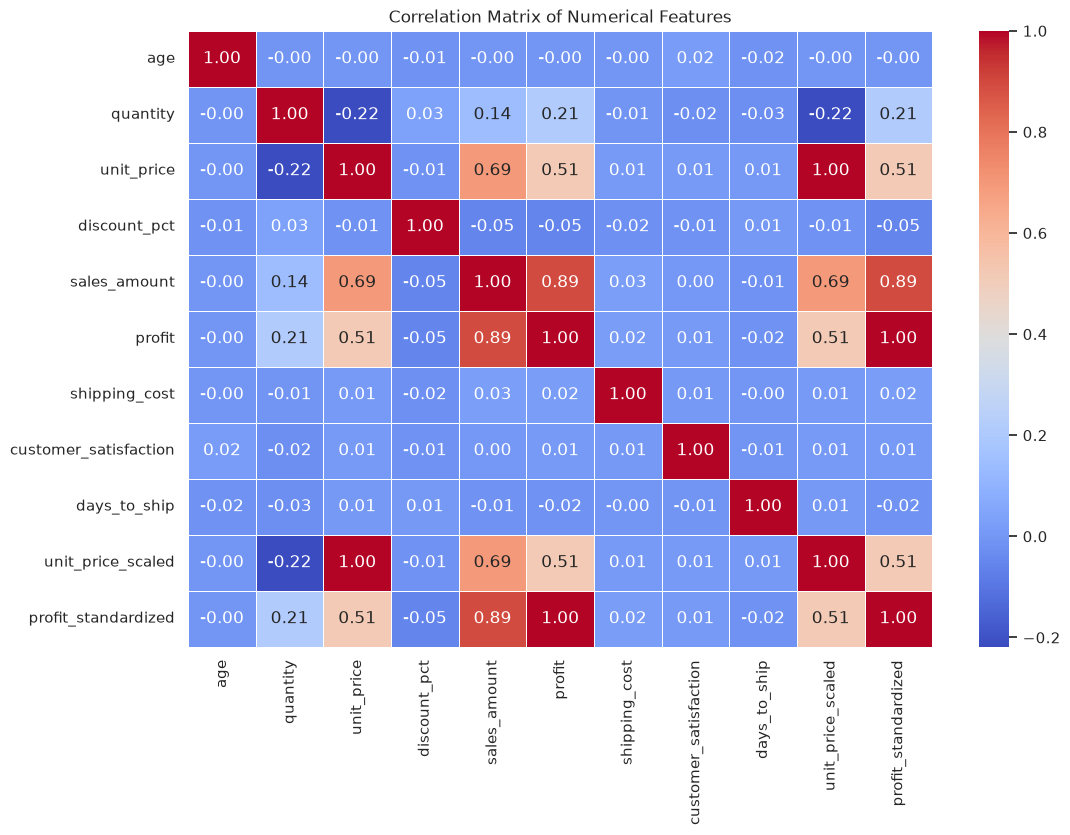

In [37]:
# Visualize the correlation matrix to get a good screenshot
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()